In [15]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *

In [ ]:
olist = np.linspace(1.0, 10, 3)
wlist = np.linspace(0.01, 0.5, 3)
wd = 0.6365091993031
tlist = np.linspace(0, 100, 300)
tlen = len(tlist)
disorder = 0.0
qargs = {"A": 0.3}
realizations = 1
N = 4

In [19]:
Rtau_scar_all = []
for ohm in olist:
    H0, H1_list, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N, indv_qubit=True, ohms=ohm)
    bandwidth = eigenvalues[-1] - eigenvalues[0]
    wd = 0.6365091993031 * ohm
    Rtau_scar = np.zeros(tlen)
    for _ in range(realizations):
        dw = np.random.uniform(-disorder, disorder, N)
        args = {"A": 0.1}
        omega_list = wd + dw
        H = [H0]

        for r in range(N):
            args[f"wd{r}"] = omega_list[r]
            H.append([H1_list[r], make_coeff(r)])

        H = qt.QobjEvo(H, args=args)
        psi_t = qt.sesolve(H, eigenstates[0], tlist, e_ops=[H0])
        Rtau_scar += np.array(np.real(psi_t.expect[0] - psi_t.expect[0][0]) / bandwidth)
    Rtau_scar_all.append(Rtau_scar / realizations)

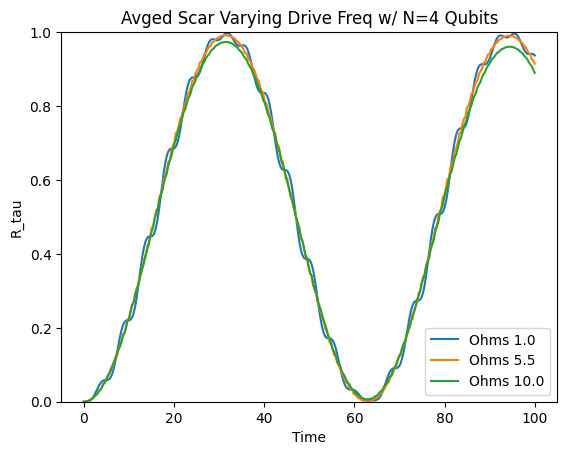

In [20]:
for i in range(len(Rtau_scar_all)):
    plt.plot(tlist, Rtau_scar_all[i], label=f"Ohms {olist[i]}")

plt.title(f"Avged Scar Varying Drive Freq w/ N={N} Qubits")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()

In [ ]:
Rtau_qubit_all = []
for wm in wlist:
    qH0, qH1_list = get_random_freq_qubit_ham(N, wm=wm)
    qeigvals, qeigstates = qH0.eigenstates()
    qbandwidth = qeigvals[-1] - qeigvals[0]
    Rtau_qubit = np.zeros(tlen)
    for _ in range(realizations):
        dw = np.random.uniform(-disorder, disorder, N)
        omega_list = wm + dw
        qH = [qH0]

        for r in range(N):
            qargs[f"wd{r}"] = omega_list[r]
            qH.append([qH1_list[r], make_coeff(r)])

        qH = qt.QobjEvo(qH, args=qargs)
        qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])
        Rtau_qubit += np.array(np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qbandwidth)
    Rtau_qubit_all.append(Rtau_qubit / realizations)

NameError: name 'get_random_freq_qubit_ham' is not defined

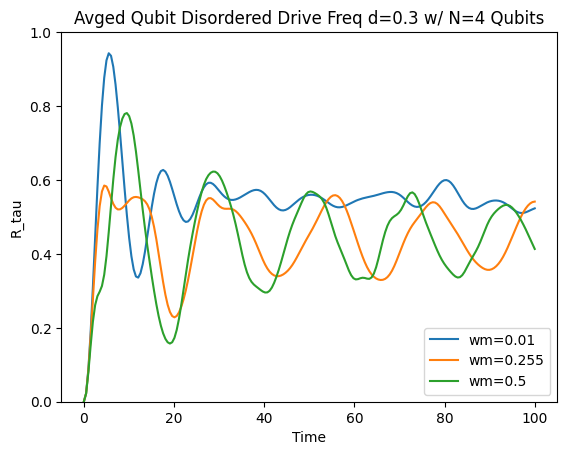

In [ ]:
for i in range(len(Rtau_qubit_all)):
    plt.plot(tlist, Rtau_qubit_all[i], label=f"wm={wlist[i]}")

plt.title(f"Avged Qubit Disordered Drive Freq d={disorder} w/ N={N} Qubits")
plt.ylabel("R_tau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.show()